In [1]:
from utils_activations import *
from utils import makefolder

rcpsize = 22
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

def projection_coefficients(act, syn_centroids, sem_centroids):
    """
    Compute fraction of norm of act explained by syn_centroids and sem_centroids.

    Args:
        act: (batch, features) tensor of activations
        syn_centroids: (batch, features) tensor of synthetic centroids
        sem_centroids: (batch, features) tensor of semantic centroids

    Returns:
        fractions: dict with keys
            'syn' : fraction of norm along syn_centroids
            'sem' : fraction of norm along sem_centroids
            'residual' : fraction of norm orthogonal to both
    """

    # Compute projection onto syn_centroids
    # proj_syn = (act ⋅ syn) / ||syn||^2 * syn
    # squared norm fraction = ||proj||^2 / ||act||^2

    def squared_norm_fraction(act, centroid):
        # elementwise dot
        dot = jnp.sum(act * centroid, axis=1, keepdims=True)
        centroid_norm_sq = jnp.sum(centroid * centroid, axis=1, keepdims=True) + 1e-8
        proj = (dot / centroid_norm_sq) * centroid
        frac = jnp.sum(proj**2, axis=1) / (jnp.sum(act**2, axis=1) + 1e-8)
        return frac  # shape: (batch,)

    syn_frac = squared_norm_fraction(act, syn_centroids)
    sem_frac = squared_norm_fraction(act, sem_centroids)

    # Residual fraction
    residual_frac = 1.0 - syn_frac - sem_frac
    residual_frac = jnp.clip(residual_frac, 0.0, 1.0)  # avoid tiny negatives due to numerical error

    fractions = {
        'syn': syn_frac,
        'sem': sem_frac,
        'residual': residual_frac
    }

    return fractions

# # -------------------------------------------------------------------------
# # Example usage
# # -------------------------------------------------------------------------
# fractions = projection_coefficients(act_A, syn_centroids_A, sem_centroids_A)

# print("Mean fraction along syn_centroids:", fractions['syn'].mean())
# print("Mean fraction along sem_centroids:", fractions['sem'].mean())
# print("Mean residual fraction:", fractions['residual'].mean())

def projection_coefficients_lex(act, syn_centroids, sem_centroids, lex_centroids):
    """
    Compute fraction of norm of act explained by lex_centroids, syn_centroids, and sem_centroids.

    Args:
        act: (batch, features) tensor of activations
        syn_centroids: (batch, features) tensor of syntactic centroids
        sem_centroids: (batch, features) tensor of semantic centroids
        lex_centroids: (batch, features) tensor of lexicon centroids

    Returns:
        fractions: dict with keys
            'lex' : fraction of norm along lex_centroids
            'syn' : fraction of norm along syn_centroids
            'sem' : fraction of norm along sem_centroids
            'residual' : fraction of norm orthogonal to all
    """
    def squared_norm_fraction(act, centroid):
        dot = jnp.sum(act * centroid, axis=1, keepdims=True)
        centroid_norm_sq = jnp.sum(centroid * centroid, axis=1, keepdims=True) + 1e-8
        proj = (dot / centroid_norm_sq) * centroid
        frac = jnp.sum(proj**2, axis=1) / (jnp.sum(act**2, axis=1) + 1e-8)
        return frac  # shape: (batch,)

    lex_frac = squared_norm_fraction(act, lex_centroids)
    if syn_centroids != None:
      syn_frac = squared_norm_fraction(act, syn_centroids)
    else:
      syn_frac = 0.
    if sem_centroids != None:
      sem_frac = squared_norm_fraction(act, sem_centroids)
    else:
      sem_frac = 0.

    residual_frac = 1.0 - lex_frac - syn_frac - sem_frac
    # residual_frac = jnp.clip(residual_frac, 0.0, 1.0)

    return {
        'lex': lex_frac,
        'syn': syn_frac,
        'sem': sem_frac,
        'residual': residual_frac
    }

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt
import numpy as np

n_files = 21
model_name = 'deepseek'
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length 

for avg_tokens in [0,1]:

  input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]

  all_activations_A = collect_data(input_path_A, 
                                  min_token_length, 
                                  n_files,
                                  model_name,
                                  avg_tokens,
                                  )

  layers = list(range(1, depths[model_name] + 1))
  layer_vals = reduce_list_half_preserve_extremes(layers)

  syn_means = []
  sem_means = []
  residual_means = []
  cos_means = []
  cos_stds = []

  for layer in tqdm(layer_vals,desc='layer_vals'):
      act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing_sem_data(
          model_name=model_name,
          all_activations=all_activations_A, 
          layer=layer, 
          space_index='A',
          global_center_flag=global_center_flag,
          min_token_length=min_token_length,
          avg_tokens=avg_tokens,
          n_tokens=n_tokens,
      )

      # ### removing mutual ovelap
      syn_centroids_A = batched_remove_centroid_projections(
          syn_centroids_A,
          jnp.arange(sem_centroids_A.shape[0], dtype=jnp.int32),
          sem_centroids_A
      )

      cos = np.array(cosine_similarity(syn_centroids_A, sem_centroids_A))
      cos_means.append(cos.mean())
      cos_stds.append(cos.std())

      fractions = projection_coefficients(act_A, syn_centroids_A, sem_centroids_A)

      syn_means.append(np.mean(np.array(fractions['syn'])))
      sem_means.append(np.mean(np.array(fractions['sem'])))
      residual_means.append(np.mean(np.array(fractions['residual'])))

  # Convert to numpy arrays for easier stacking
  syn_means = np.array(syn_means)
  sem_means = np.array(sem_means)
  residual_means = np.array(residual_means)

  rel_depths = (np.array(layer_vals)) / (depths[model_name])

  ### Saving
  resultsfolder = makefolder(base='results/norms/syn-sem/',
                          create_folder=True,
                          model_name=model_name,
                          avg_tokens=avg_tokens,
                          min_token_length=min_token_length,
                          global_center_flag=global_center_flag,
                          )
  os.makedirs(resultsfolder, exist_ok=True)

  layer_vals = np.array(layer_vals)
  rel_depths = np.array(rel_depths)
  cos_means = np.array(cos_means)
  cos_stds = np.array(cos_stds)

  np.savez(
      os.path.join(
          resultsfolder,
          f"norms.npz"
      ),
      layer_vals=layer_vals,
      rel_depths=rel_depths,
      syn_means=syn_means,
      sem_means=sem_means,
      residual_means=residual_means,
      cos_means=cos_means,
      cos_stds=cos_stds,
  )

deepseek dtype: torch.bfloat16


Collect File:   0%|          | 0/21 [00:00<?, ?it/s]

Collect File: 100%|██████████| 21/21 [01:51<00:00,  5.33s/it]


all_hidden_states["layer_0"].shape=torch.Size([2018, 3, 7168])
importing took 1.9443115790685017 m


layer_vals: 100%|██████████| 30/30 [01:38<00:00,  3.29s/it]


deepseek dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:06<00:00,  3.20it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 7168])
importing took 0.12017395496368408 m


layer_vals: 100%|██████████| 30/30 [00:18<00:00,  1.58it/s]


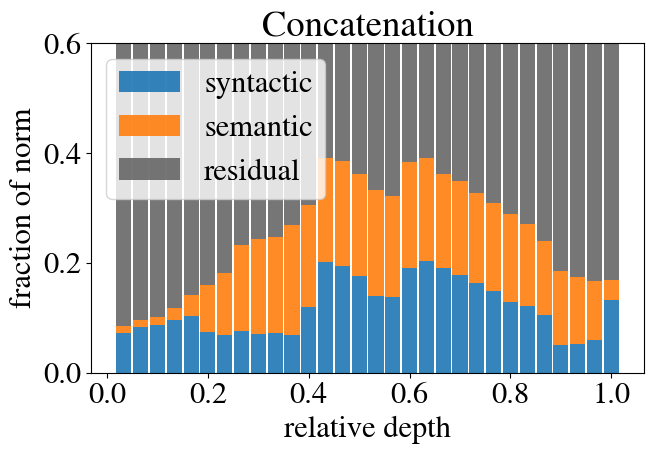

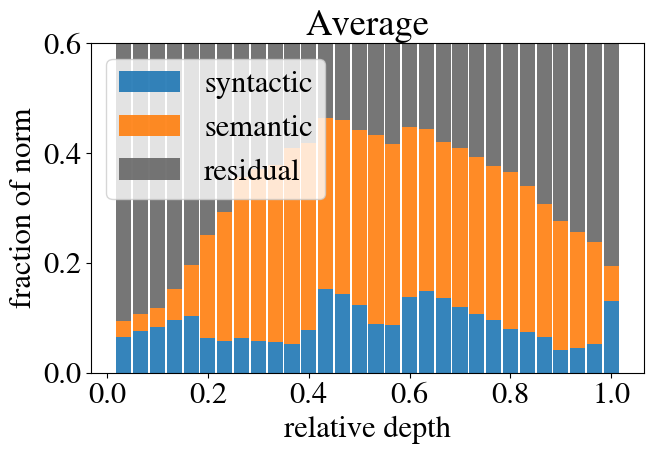

In [3]:
import os
import numpy as np

model_name = 'deepseek'
data_var = 'sem'
avg_tokens_list = [0,1]
min_token_length = 3
global_center_flag = 1

for avg_tokens in avg_tokens_list:
    resultsfolder = makefolder(base='results/norms/syn-sem/',
                            model_name=model_name,
                            avg_tokens=avg_tokens,
                            min_token_length=min_token_length,
                            global_center_flag=global_center_flag,
                            )
    npz_path = os.path.join(
        resultsfolder,
        f"norms.npz"
    )

    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    bar_width = 0.03  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)


    ax.bar(x, syn_means, width=bar_width, color="#1f77b4", label="syntactic", alpha=0.9)
    ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color="#ff7f0e", label="semantic", alpha=0.9)
    ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, color="#676767", label="residual", alpha=0.9)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
    ax.set_xlabel("relative depth", fontsize=rcpsize)
    ax.set_ylabel("fraction of norm", fontsize=rcpsize)

    # box = ax.get_position()
    # ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.legend(loc='upper left')
    ax.set_ylim(0, .6)
    title = 'Concatenation' if avg_tokens == 0 else 'Average'
    ax.set_title(title)
    plt.tight_layout()
    figs_folder = f'results/figs/norms/'
    os.makedirs(figs_folder, exist_ok=True)
    fig.savefig(figs_folder + f'{model_name}_syn_sem_norms_avg_{avg_tokens}.pdf')
    plt.show()


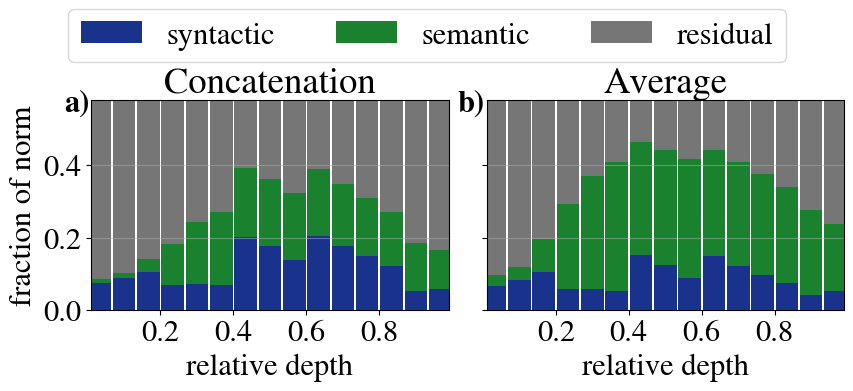

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

model_name = 'deepseek'
data_var = 'sem'
avg_tokens_list = [0, 1]
min_token_length = 3
global_center_flag = 1

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, avg_tokens in enumerate(avg_tokens_list):
    ax = axes[i]

    resultsfolder = makefolder(
        base='results/norms/syn-sem/',
        model_name=model_name,
        avg_tokens=avg_tokens,
        min_token_length=min_token_length,
        global_center_flag=global_center_flag,
    )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # --- your original x-axis logic ---
    bar_width = 0.062  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)
    # -----------------------------------

    # keep half of the bars: take every second one (0,2,4,...)
    idx = np.arange(n_layers)
    mask = (idx % 2 == 0)
    x_plot = x[mask]
    syn_plot = syn_means[mask]
    sem_plot = sem_means[mask]
    residual_plot = residual_means[mask]

    ax.bar(
        x_plot, syn_plot,
        width=bar_width,
        label="syntactic",
        alpha=0.9,
    )
    ax.bar(
        x_plot, sem_plot,
        width=bar_width,
        bottom=syn_plot,
        label="semantic",
        alpha=0.9,
    )
    ax.bar(
        x_plot, residual_plot,
        width=bar_width,
        bottom=syn_plot + sem_plot,
        label="residual",
        alpha=0.9,
        color="#676767",
    )

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])

    if i == 0:
        ax.set_ylabel("fraction of norm", fontsize=rcpsize)
    ax.set_xlabel("relative depth", fontsize=rcpsize)

    ax.set_ylim(0, 0.58)
    ax.set_xlim(0.01, .99)
    ax.grid(True, axis="y", alpha=0.5)

    title = 'Concatenation' if avg_tokens == 0 else 'Average'
    ax.set_title(title)

# Shared legend using handles from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    axes[i].text(
        -0.005, 1.05,      # x, y in axis coordinates
        label,
        transform=axes[i].transAxes,  # coordinates relative to the axes
        fontsize=rcpsize,
        fontweight='bold',
        va='top',
        ha='right'
    )

figs_folder = 'results/figs/norms/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, f"{model_name}_syn_sem_norms_bars_both_half.pdf"))
plt.show()

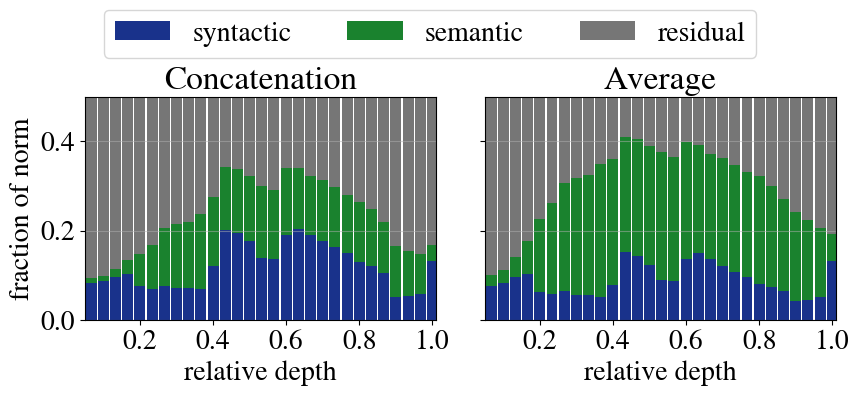

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

model_name = 'deepseek'
data_var = 'sem'
avg_tokens_list = [0, 1]
min_token_length = 3
global_center_flag = 1

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, avg_tokens in enumerate(avg_tokens_list):
    ax = axes[i]

    resultsfolder = makefolder(
        base='results/norms/syn-sem/',
        model_name=model_name,
        avg_tokens=avg_tokens,
        min_token_length=min_token_length,
        global_center_flag=global_center_flag,
    )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # --- your original x-axis logic ---
    bar_width = 0.03  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)
    # -----------------------------------

    ax.bar(x, syn_means,
           width=bar_width,
           label="syntactic",
           alpha=0.9)
    ax.bar(x, sem_means,
           width=bar_width,
           bottom=syn_means,
           label="semantic",
           alpha=0.9)
    ax.bar(x, residual_means,
           width=bar_width,
           bottom=syn_means + sem_means,
           label="residual",
           alpha=0.9,
            color="#676767",)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])

    if i == 0:
        ax.set_ylabel("fraction of norm", fontsize=rcpsize)
    ax.set_xlabel("relative depth", fontsize=rcpsize)

    ax.set_ylim(0, 0.5)
    ax.set_xlim(0.05,1.01)
    ax.grid(True, axis="y", alpha=0.5)

    title = 'Concatenation' if avg_tokens == 0 else 'Average'
    ax.set_title(title)

# Shared legend using handles from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=3,
           bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0, 0, 1, 0.95])

figs_folder = 'results/figs/norms/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, f"{model_name}_syn_sem_norms_bars_both.pdf"))
plt.show()


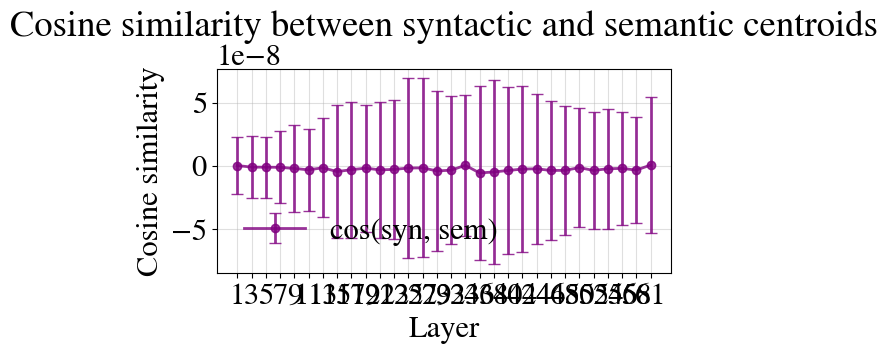

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(layer_vals))

ax.errorbar(
    x, cos_means, yerr=cos_stds, 
    fmt='-o', capsize=4, lw=2,
    color='purple', alpha=0.8, 
    label='cos(syn, sem)'
)

ax.set_xticks(x)
ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between syntactic and semantic centroids")
ax.legend(frameon=False)
ax.grid(alpha=0.4)

# ax.set_ylim(-.05,1.05)

plt.tight_layout()
plt.show()

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os

def all_pairwise_cosine(X, eps=1e-8):
    X_norm = X / (jnp.linalg.norm(X, axis=1, keepdims=True) + eps)
    sim = X_norm @ X_norm.T
    return sim

# Compute cosine similarity matrix (N x N)
cos_sim = all_pairwise_cosine(syn_centroids_A)

# Get upper triangle (no diagonal)
triu_idx = jnp.triu_indices(cos_sim.shape[0], k=1)
cos_sim_vals = cos_sim[triu_idx]

# Convert to numpy for plotting
cos_sim_vals = np.array(cos_sim_vals)

plt.figure(figsize=(7, 5))
plt.hist(cos_sim_vals, bins=50, color="#1f77b4", alpha=0.9, edgecolor="black")
plt.xlabel("cosine similarity", fontsize=14)
plt.ylabel("count", fontsize=14)
plt.title(f"Cosine similarities between syntactic centroids", fontsize=14)
plt.grid(alpha=0.5)
plt.tight_layout()

os.makedirs("results/figs/norms", exist_ok=True)
plt.savefig("results/figs/norms/syn_centroid_cosine_hist.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
global_center_flag = 1

layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)


for avg_tokens in [0]:

  if avg_tokens:
    min_token_length = 3
  else:
    min_token_length = 1
  n_tokens = min_token_length 

  input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]

  if all_activations_A is None:
    all_activations_A = collect_data(input_path_A, 
                                    min_token_length, 
                                    n_files,
                                    model_name,
                                    avg_tokens,
                                    )

lex_means = []
syn_means = []
sem_means = []
residual_means = []

# Load lexicon representations (layer 0)
lex_centroids_A, _, _, global_center_lex = preprocessing(
    all_activations_A,
    layer=0,
    space_index='A',
    global_center_flag=global_center_flag,
    avg_tokens=avg_tokens,
    n_tokens=n_tokens,
    centroids=False
)

for layer in layer_vals:
    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing(
        all_activations_A, 
        layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
        centroids=False,
    )

    if sem_centroids_A is not None:
      sem_centroids_A = batched_remove_centroid_projections(
          sem_centroids_A,
          jnp.arange(act_A.shape[0], dtype=jnp.int32),
          syn_centroids_A
      )

    fractions = projection_coefficients_lex(
        act_A, syn_centroids_A, sem_centroids_A, lex_centroids=lex_centroids_A
    )

    lex_means.append(np.mean(np.array(fractions['lex'])))
    syn_means.append(np.mean(np.array(fractions['syn'])))
    sem_means.append(np.mean(np.array(fractions['sem'])))
    residual_means.append(np.mean(np.array(fractions['residual'])))

# Convert to numpy arrays
lex_means = np.array(lex_means)
syn_means = np.array(syn_means)
sem_means = np.array(sem_means)
residual_means = np.array(residual_means)

# Plot stacked bars
fig, ax = plt.subplots(figsize=(6, 4))

bar_width = 0.6
x = np.arange(len(layer_vals))

# ax.bar(x, syn_means, width=bar_width, color="#1f77b4", label="syntactic", alpha=0.9)
# ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color="#ff7f0e", label="semantic", alpha=0.9)
ax.bar(x, lex_means, width=bar_width, bottom=syn_means+sem_means, color="#9467bd", label="lexicon", alpha=0.9)
ax.bar(x, residual_means, width=bar_width, bottom=lex_means + syn_means + sem_means, color="#676767", label="residual", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of Norm")
ax.set_title("Decomposition of activation norm across layers (with lexicon)")

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
global_center_flag = 1

layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)


for avg_tokens in [0]:

  if avg_tokens:
    min_token_length = 3
  else:
    min_token_length = 1
  n_tokens = min_token_length 

  input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]

  if all_activations_A is None:
    all_activations_A = collect_data(input_path_A, 
                                    min_token_length, 
                                    n_files,
                                    model_name,
                                    avg_tokens,
                                    )

def cosine_similarity(a, b, eps=1e-8):
    """Compute cosine similarity per row between two (N, D) matrices."""
    dot = jnp.sum(a * b, axis=1)
    norm_a = jnp.linalg.norm(a, axis=1)
    norm_b = jnp.linalg.norm(b, axis=1)
    return dot / (norm_a * norm_b + eps)


# -------------------------------------------------------------------------
# Compute cosine similarity between lexical representations (layer 0)
# and activations at every layer
# -------------------------------------------------------------------------

# Load lexical (layer 0) representations
lex_A, _, _, global_center_lex = preprocessing(
    all_activations_A,
    layer=0,
    space_index='A',
    global_center_flag=global_center_flag,
    avg_tokens=avg_tokens,
    n_tokens=n_tokens,
    centroids=False,
)

lex_A = jnp.array(lex_A)
print(np.linalg.norm(lex_A,axis=1).mean())

cos_means = []
cos_stds = []

for layer in layer_vals:
    act_A, _, _, global_center_A = preprocessing(
        all_activations_A,
        layer,
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
        centroids=False,
    )
    print(np.linalg.norm(act_A,axis=1).mean())

    cos = np.array(cosine_similarity(lex_A, act_A))
    cos_means.append(cos.mean())
    cos_stds.append(cos.std())

# -------------------------------------------------------------------------
# Plot cosine similarity
# -------------------------------------------------------------------------

import numpy as np

# Load data from aux.txt (skipping the header line)
data = np.loadtxt("aux.txt", skiprows=1)

# Split into columns
hf_layers = data[:, 0].astype(int)
hf_cosine_sims = data[:, 1]


fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(1,len(layer_vals)+1)

ax.errorbar(
    x/max(x), cos_means, yerr=cos_stds,
    fmt='-o', capsize=4, lw=2,
    color='darkgreen', alpha=0.8,
    label='cos(lexical, activations)'
)

ax.plot(hf_layers/max(hf_layers),hf_cosine_sims, marker='o', color='orange', label='HF cos(lexical, activations)')

# ax.set_xticks(x)
# ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between lexical representation and activations")
ax.legend(frameon=False)
ax.grid(alpha=0.4)
# ax.set_ylim(-.05, 1.05)

plt.tight_layout()
plt.show()
